# Executive summary
- Novel method for combining four sets of disjoint tiles with better calibration than each set alone.
- Illustrate with simple example showcasing good performance and solving problems of original tiles (without needed to retrain BLISS).

## Variational Distribution
We parameterize the following variational distribution:
\begin{equation}
  \label{eq:vardist}
  \begin{split}
    A_{i} \sim \mathrm{Bernoulli}(\alpha_{i}) \\
    \ell_{i} \sim \mathcal N_{T_{i}} (\mu_{i}, \Sigma_{i})
  \end{split}
\end{equation}
where subscript $T_{i}$ means trucation to the tile $T_{i}$.
The variational posterior factorizes over tiles:
$$
q(\{A_i, \ell_i\}) = \prod_{i=1}^T \alpha_i^{A_i} q_i^\ell(\ell_i) ^{A_i} (1 - \alpha_i)^{1 - A_i}.
$$
Unlike in the previous, non-overlapping version, we do not assume that each tile $T_i$ is disjoint.
However, we assume that the tiles can be organized into **layers**, such that, within a layer $j$, each tile $T_{j, k}$ is disjoint with other tiles in layer $j$.
$$
q(\{A_{j, k}, \ell_{j, k}\}) = \prod_{j=1}^J \prod_{k} \alpha_j^{A_{j, k}} q_{j, k}^\ell(\ell_{j, k}) ^{A_{j, k}} (1 - \alpha_{j, k})^{1 - A_{j, k}}.
$$

We add an additional condition that two tiles with overlap cannot be both "on"
$$
A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing
$$
As a result of this assumption, there is at most one object in the area of tile $T_i$. However, with overlap, it could be the case that $T_i$ did not **generate** that object.

Thus, our variational posterior is:
$$
\tilde q (\{\ell_{j, k}, A_{j, k}\}) = \frac{q (\{\ell_n, A_n\}) 1[A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing]}{\int q (\{\ell_n, A_n\}) 1[A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing] d \{\ell_n, A_n\}}
$$
Because of the denominator, this distribution is intractable.

We observe that the distribution factorizes along the tiles $k$ in layer $l$.

$$
\begin{split}
\tilde q(\{A_{j, k}, \ell_{j, k}\}_{k} | \{A_{j^\prime, k}, \ell_{j^\prime, k}\}_{j^\prime \ne j, k}) &\propto \prod_{k} \alpha_j^{A_{j, k}} q_{j, k}^\ell(\ell_{j, k}) ^{A_{j, k}} (1 - \alpha_{j, k})^{1 - A_{j, k}} \prod_{j^\prime} \prod_{{k^\prime}} \alpha_{j^\prime}^{A_{{j^\prime}, {k^\prime}}} q_{{j^\prime}, {k^\prime}}^\ell(\ell_{{j^\prime}, {k^\prime}}) ^{A_{{j^\prime}, {k^\prime}}} (1 - \alpha_{{j^\prime}, {k^\prime}})^{1 - A_{{j^\prime}, {k^\prime}}} 1[A_{{j}, {k}} A_{j^\prime, k^\prime} = 0 ~ \text{if} ~ T_{j, k} \cap T_{j^\prime, k^\prime} \ne \varnothing]\\
&\propto \prod_{k} \alpha_j^{A_{j, k}} q_{j, k}^\ell(\ell_{j, k}) ^{A_{j, k}} (1 - \alpha_{j, k})^{1 - A_{j, k}} \prod_{j^\prime} \prod_{{k^\prime}} 1[A_{{j}, {k}} A_{j^\prime, k^\prime} = 0 ~ \text{if} ~ T_{j, k} \cap T_{j^\prime, k^\prime} \ne \varnothing] \\
&\equiv \prod_{k} \tilde q(A_{j, k}, \ell_{j, k} | \{A_{j^\prime, k}, \ell_{j^\prime, k}\}_{j^\prime \ne j, k})
\end{split}
$$

$$
\begin{split}
\tilde q(A_{j, k}, \ell_{j, k} | \{A_{j^\prime, k}, \ell_{j^\prime, k}\}_{j^\prime \ne j, k}) &\propto \alpha_j^{A_{j, k}} q_{j, k}^\ell(\ell_{j, k}) ^{A_{j, k}} (1 - \alpha_{j, k})^{1 - A_{j, k}} \prod_{j^\prime} \prod_{{k^\prime}} 1[A_{{j}, {k}} A_{j^\prime, k^\prime} = 0 ~ \text{if} ~ T_{j, k} \cap T_{j^\prime, k^\prime} \ne \varnothing]\\
&= \begin{cases}
\alpha_{j, k}^{A_{j, k}} q_{j, k}^\ell(\ell_{j, k}) ^{A_{j, k}} (1 - \alpha_{j, k})^{1 - A_{j, k}} ~ \text{if no overlap} \\
0 ~ \text{otherwise} \\
\end{cases}
\end{split}
$$

Thus, conditioned on the tiles in other layers, the distribution of each tile is Bernoulli with probability either equal to $\alpha_{j, k}$ or $0$ ($\alpha^\star_{j, k}$).

Because these conditional distributions are tractable, we can utilize Gibbs sampling to sample from $\tilde q (\{\ell_{j, k}, A_{j, k}\})$.

## FAVI objective

Now, we can re-write the density as follows:
$$
  \begin{split}
    q(\{\ell_{j, n}, A_{j, n}\} |\{\ell_{j^\prime, n}, A_{j^\prime, n}\}_{j^\prime \ne j}) &= \prod_{k} {\alpha_{j, k}^\star}^{A_{j, k}} q_{j, k}^\ell(\ell_{j, k}) ^{A_{j, k}} (1 - {\alpha_{j, k}^\star})^{1 - A_{j, k}} \\
     &= \prod_{k} {\alpha_{j, k}^\star}^{\sum_n A_{j, k, n}} q_{j, k}^\ell(\sum_n A_{j, k, n}\ell_{j, n}) ^{\sum_n A_{j, k, n}} (1 - {\alpha_{j, k}^\star})^{1 - \sum_n A_{j, k, n}} \\
     &= \prod_{k: \sum_n A_{j, k, n} = 1} {\alpha_{j, k}^\star} q_{j, k}^\ell(\sum_n A_{j, k, n}\ell_{j, n}) \prod_{k: \sum_n A_{j, k, n} = 0} (1 - {\alpha_{j, k}^\star})
  \end{split}
$$

Given that the other tiles are off, we recover the original, non-overlapping tile density:
$$
  \begin{split}
    q(\{\ell_{j, n}, A_{j, n}\} | \{A_{j^\prime, n} = 0\}_{j^\prime \ne j}) &= \prod_{k: \sum_n A_{j, k, n} = 1} {\alpha_{j, k}} q_{j, k}^\ell(\sum_n A_{j, k, n}\ell_{j, n}) \prod_{k: \sum_n A_{j, k, n} = 0} (1 - {\alpha_{j, k}})
  \end{split}
$$

We make one more simplifying assumption: The distribution of the padded tile around $T_{j, n}$, $X_{j, n}$ is the same whether we condition on all other layers being zero or just the tiles overlapping with just $T_{j, n}$.

$P(X_{j, n} | \ell_{j, n}, A_{j, n}, \{A_{j^\prime, n} = 0\}) = P(X_{j, n} | \ell_{j, n}, A_{j, n}, \{A_{(j^\prime, k^\prime) \in \textrm{overlap(j, k)\}}}=0 \})$

This assumption is necessary for quick training. Otherwise, we would need to train over Gibbs samples of $A_{j, n}$ given the no-overlapping assumption. In reality, the distribution of objects is likely not very different, and if they are different, not likely to impact the encoder.

This "conditional" FAVI objective for a particular tile $T_{j, k}$ turns out to be the same as the original FAVI objective for non-overlapping tiles. 
$$
  \begin{split}
&\int \log q(\ell_{j, n}, A_{j, n} | X_{j, k}, \{A_{(j^\prime, k^\prime) \in \textrm{overlap(j, k)\}}}=0 \}) dP(X_{j, n} | \ell_{j, n}, A_{j, n}, \{A_{(j^\prime, k^\prime) \in \textrm{overlap(j, k)\}}}=0 \}) d P(\ell_{j, n} | A_{j, n}) P(A_{j, n} | \{A_{j^\prime, n} = 0\}_{j^\prime \ne j}) \\
&= \int \log q(\ell_{j, n}, A_{j, n} | \{A_{j^\prime, n} = 0\}_{j^\prime \ne j}) dP(X_{j, n} | \ell_{j, n}, A_{j, n}, \{A_{j^\prime, n} = 0\}) \frac {1}{h^2} d\ell_{j, n} \lambda^{A_{j, n}} ( 1 - \lambda)^{1 - A_{j, n}} d A_{j, n} \\
&= \int \log \left (\alpha_{j, k}^{A_{j, k}} q_{j, k}^\ell(\ell_{j, k}) ^{A_{j, k}} (1 - \alpha_{j, k})^{1 - A_{j, k}} \right ) dP(X_{j, n} | \ell_{j, n}, A_{j, n}, \{A_{j^\prime, n} = 0\}) \frac {1}{h^2} d\ell_{j, n} \lambda^{A_{j, n}} ( 1 - \lambda)^{1 - A_{j, n}} d A_{j, n} \\
  \end{split}
$$
where the base measure for location $\ell_{j, n}$ is Lebesgue and base measure for $A_{j, n}$ is discrete over $\{0, 1\}$.
The tile-specific parameters ($\alpha_{j, k}, \mu_{j, k}, \sigma_{j, k}$) implicitly depend on $X_{j, k}$ via a neural-network (NN) encoder.
If we amortize across layers (i.e. use the same NN encoder), then the training procedure is unchanged from the original BLISS.
This justifies our experiment below using the orignally-trained BLISS encoder.


This "conditional" FAVI objective for a particular tile $T_{j, k}$ turns out to be the same as the original FAVI objective for non-overlapping tiles. 
$$
  \begin{split}
\int \log q(\ell_{j, n}, A_{j, n} | \{A_{j^\prime, n} = 0\}_{j^\prime \ne j}) d P(\ell_{j, n} | A_{j, n}) P(A_{j, n} | \{A_{j^\prime, n} = 0\}_{j^\prime \ne j}) &= \int \log q(\ell_{j, n}, A_{j, n} | \{A_{j^\prime, n} = 0\}_{j^\prime \ne j}) \frac {1}{h^2} d\ell_{j, n} \lambda^{A_{j, n}} ( 1 - \lambda)^{1 - A_{j, n}} d A_{j, n} \\
&= \int \log \left (\alpha_{j, k}^{A_{j, k}} q_{j, k}^\ell(\ell_{j, k}) ^{A_{j, k}} (1 - \alpha_{j, k})^{1 - A_{j, k}} \right ) \frac {1}{h^2} d\ell_{j, n} \lambda^{A_{j, n}} ( 1 - \lambda)^{1 - A_{j, n}} d A_{j, n} \\
  \end{split}
$$
where the base measure for location $\ell_{j, n}$ is Lebesgue and base measure for $A_{j, n}$ is discrete over $\{0, 1\}$.
If we amortize across layers (i.e. use the same NN encoder), then the training procedure is unchanged from the original BLISS.
This justifies our experiment below using the orignally-trained BLISS encoder.

# Inference
We need to infer the marginal probability of $P(A_i)$; the current output is the probability of $A_i$ given no other overlapping tiles.

This can be accomplished with a simple MCMC algorithm, where $P(A_i = 1 | A_{overlap(i)}) = 0$ if any overlapping tiles are present and $\alpha_i$ otherwise.

## Algorithm
1. Start at $A_i = 0$ everywhere.
1. For each iteration...
  1. For each layer of disjoint tiles $k$
    1. For each tile $A_{i, k}$ (parallelizable)
      1. Evaluate whether any tiles overlapping with $A_{i, k}$ are on.
      1. Sample $A_{i, k} = 1$ with probability $\alpha_i 1[A_{overlap(i) = 0}]$.

# Simple example
Consider original tiles + one overlapping layer where both height and width are shifted by 2 pixels.

In [110]:
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import OmegaConf
from einops import rearrange, repeat, reduce
import torch

from case_studies.sdss_galaxies_vae.reconstruction import load_models, reconstruct_scene_at_coordinates

In [111]:
import os
os.environ["BLISS_HOME"] = "/home/dereklh/projects/bliss/"

In [112]:
with initialize(config_path="../sdss_galaxies_vae/config", job_name="overlap"):
    cfg = compose(config_name="config")   

In [113]:
simulated_dataset = instantiate(cfg.datasets.simulated)

In [114]:
batch_size=1
n_tiles_h=5
n_tiles_w=5
# tile_catalog = simulated_dataset.sample_prior(batch_size, n_tiles_h, n_tiles_w)
# tc2 = torch.load("catalog_with_stuff.pt")
# for (h, w) in ((0, 4), (3, 1)):
#     tile_catalog.n_sources[0, h, w] = 1
#     tile_catalog.locs[0, h, w] = tc2.locs[0, h, w]
#     for k, v in tc2.items():
#         tile_catalog[k][0, h, w] = v[0, h, w]
# torch.save(tile_catalog, "catalog.pt")
tile_catalog = torch.load("catalog.pt")

In [115]:
img, bg = simulated_dataset.simulate_image_from_catalog(tile_catalog)

In [116]:
import matplotlib.pyplot as plt

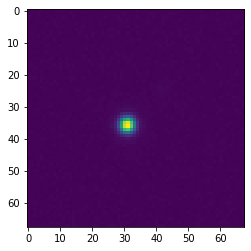

In [117]:
%matplotlib inline
plt.imshow(img[0, 0])

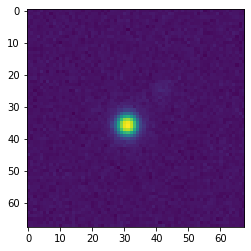

In [118]:
plt.imshow(img[0, 0].log())

In [119]:
tile_catalog["galaxy_params"].shape

torch.Size([1, 5, 5, 1, 7])

In [120]:
tile_catalog.n_sources

tensor([[[0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 1, 0, 0, 0],
         [0, 0, 1, 0, 0]]])

In [121]:
# load bliss
device = torch.device(cfg.reconstruct.device)
decoder, encoder, _ = load_models(cfg, device)
bp = 24
h, w = img.shape[2], img.shape[3]
# img_recon, tile_map_recon = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h-bp), (bp, w-bp))
img_recon, tile_map_recon = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 80.03it/s]


In [122]:
tile_map_recon.n_sources

tensor([[[0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 1, 0, 0, 0],
         [0, 0, 0, 0, 0]]], device='cuda:0')

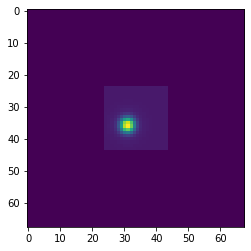

In [123]:
plt.imshow(torch.nn.functional.pad(img_recon[0, 0], (bp, bp, bp, bp)))

In [124]:
tile_map_recon["n_source_log_probs"][0, :, :, 0, 0].exp()

tensor([[2.2761e-02, 2.2524e-03, 3.3413e-04, 6.9171e-04, 9.6066e-01],
        [7.6713e-03, 3.9799e-03, 1.6322e-03, 1.1926e-03, 3.5558e-03],
        [4.3355e-03, 6.8859e-02, 1.3482e-02, 3.8137e-03, 2.7901e-04],
        [7.9205e-04, 9.7077e-01, 9.3835e-04, 1.5243e-02, 1.3433e-04],
        [1.2064e-03, 3.8350e-03, 2.4387e-02, 1.9414e-03, 4.7309e-04]],
       device='cuda:0')

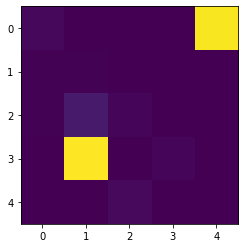

In [125]:
plt.imshow(tile_map_recon["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

In [126]:
tile_map_recon.locs[0, 3, 1, 0]

tensor([0.0479, 0.8263], device='cuda:0')

In [127]:
tile_catalog.locs[0, 3, 1, 0]

tensor([0.0322, 0.8106])

In [128]:
tile_catalog2 = tile_catalog.copy()
tile_catalog2.locs = tile_catalog.locs.clone()
tile_catalog2.locs[0, 3, 1, 0] = 0.999

In [129]:
img2, bg2 = simulated_dataset.simulate_image_from_catalog(tile_catalog2)

In [130]:
img_recon2, tile_map_recon2 = reconstruct_scene_at_coordinates(encoder, decoder, img2, bg2, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 63.00it/s]


In [131]:
tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0].exp()

tensor([[4.4309e-05, 8.7074e-05, 6.3510e-05, 2.7352e-04, 9.8496e-01],
        [1.6934e-03, 2.0089e-03, 3.2117e-04, 9.5023e-04, 1.8554e-03],
        [4.3903e-03, 4.3574e-03, 3.3106e-03, 2.0246e-03, 1.2502e-03],
        [2.8492e-03, 1.1756e-01, 1.6911e-01, 6.8137e-03, 1.5630e-04],
        [1.1325e-03, 1.4152e-01, 9.8693e-02, 7.4111e-03, 8.7829e-05]],
       device='cuda:0')

In [132]:
tile_map_recon2["n_source_log_probs"][0, 3:5, 1:3, 0, 0].exp().sum()

tensor(0.5269, device='cuda:0')

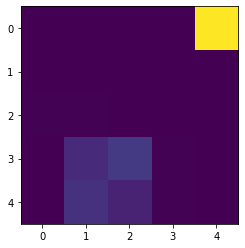

In [133]:
plt.imshow(tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

# Overlapping procedure
First, we shift the input image by two pixels in each direction and feed each to the encoder separately.

In [134]:
def make_imgs_and_bgs():
    imgs = []
    bgs = []
    for w in (0, 2):
        for h in (0, 2):
            img_shifted = torch.zeros_like(img2)
            img_shifted[:, :, :(-h if h != 0 else None), :(-w if w != 0 else None)] = img2[:, :, h:, w:]
            bg_shifted = torch.zeros_like(bg2)
            bg_shifted[:, :, :(-h if h != 0 else None), :(-w if w != 0 else None)]  = bg2[:, :, h:, w:]
            if h > 0:
                img_shifted[:, :, -h:, :] = bg2[:, :, -h:, :]
                bg_shifted[:, :, -h:, :] = bg2[:, :, -h:, :]
            if w > 0:
                img_shifted[:, :, :, -w:] = bg2[:, :, :, -w:]
                bg_shifted[:, :, :, -w:] = bg2[:, :, :, -w:]
            if (h > 0) and (w > 0):
                img_shifted[:, :, -h:, -w:] = bg2[:, :, -h:, -w:]
                bg_shifted[:, :, -h:, -w:] = bg2[:, :, -h:, -w:]
            imgs.append(img_shifted)
            bgs.append(bg_shifted)
    return imgs, bgs
imgs, bgs = make_imgs_and_bgs()

In [135]:
tile_maps = []
for img, bg in zip(imgs, bgs):
    _, tile_map_shifted = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h - bp), (bp, w - bp))
    tile_maps.append(tile_map_shifted)

Encoding ptiles: 1it [00:00, 80.84it/s]
Encoding ptiles: 1it [00:00, 98.14it/s]
Encoding ptiles: 1it [00:00, 99.72it/s]
Encoding ptiles: 1it [00:00, 103.87it/s]


In [136]:
log_probs_all = torch.stack([t["n_source_log_probs"][0, :, :, 0, 0] for t in tile_maps], dim = -1)

In [311]:
prob_dbl = repeat(log_probs_all.exp(), "h w d -> (h h2) (w w2) d",h2=2, w2=2).cpu()
prob_super = torch.zeros(prob_dbl.shape[0] + 1, prob_dbl.shape[1] + 1, 4)

prob_super[:-1, :-1, 0] = prob_dbl[:, :, 0]
prob_super[1:, :-1, 1] = prob_dbl[:, :, 1]
prob_super[:-1, 1:, 2] = prob_dbl[:, :, 2]
prob_super[1:, 1:, 3] = prob_dbl[:, :, 3]

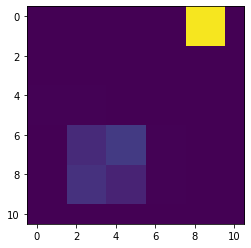

In [313]:
plt.imshow(prob_super[:, :, 0], vmax=1.0)

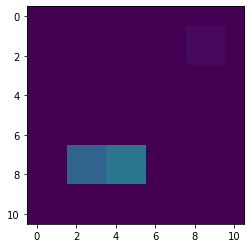

In [314]:
plt.imshow(prob_super[:, :, 1], vmax=1.0)

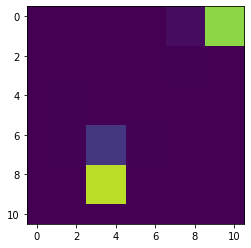

In [315]:
plt.imshow(prob_super[:, :, 2], vmax=1.0)

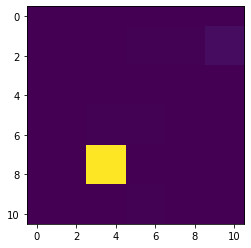

In [316]:
plt.imshow(prob_super[:, :, 3], vmax=1.0)

For each tile, the estimated probability is not the marginal probability that the tile generated an object. Rather, the probability is conditioned on no other overlapping tiles generating an object. We utilize a simple MCMC algorithm to estimate the marginal probability for each tile.

In [322]:
def get_comparison_indices(offset):
    if offset == 1:
        return 1, None, 0, -1
    elif offset == -1:
        return 0, -1, 1, None
    raise ValueError()

In [147]:
def has_no_neighbor(offset_h, offset_w, tiles_other):
    no_neighbors = (~tiles_other[:, :])
    if offset_h != 0:
        ah,bh,ch,dh = get_comparison_indices(offset_h)
        no_neighbors[ah:bh, :] &= (~tiles_other[ch:dh, :])
    if offset_w != 0:
        aw,bw,cw,dw = get_comparison_indices(offset_w)
        no_neighbors[:, aw:bw] &= (~tiles_other[:, cw:dw])
    if ((offset_h != 0) and (offset_w != 0)):
        no_neighbors[ah:bh, aw:bw] &= (~tiles_other[ch:dh, cw:dw])
    return no_neighbors

In [155]:
def has_no_neighbor_all_four(idx, tiles, offsets):
    no_neighbors = torch.ones_like(tiles[:, :, idx])
    own_offset = offsets[idx]
    for other, (offset_h, offset_w) in enumerate(offsets):
        if other != idx:
            offset_h = offset_h - own_offset[0]
            offset_w = offset_w - own_offset[1]
            n = has_no_neighbor(offset_h, offset_w, tiles[:, :, other])
            #print(n)
            no_neighbors *= n
    #print(no_neighbors)
    return no_neighbors

In [222]:
def sample_tile_marginals_from_cats(tile_maps, offsets, n_iter=1_000):
    log_probs = torch.stack([t["n_source_log_probs"][0, :, :, 0, 0] for t in tile_maps], dim = -1)
    tiles = torch.zeros(n_iter, *log_probs.shape, dtype=bool, device=log_probs.device)
    # tile_sum = torch.zeros_like(log_probs)
    for i in range(n_iter):
        for idx, offset in enumerate(offsets):
            i_prev = 0 if i==0 else i-1
            no_neighbors = has_no_neighbor_all_four(idx, tiles[i_prev], offsets)
            #print(no_neighbors)
            tiles[i, :, :, idx] = torch.rand_like(tiles[i, :, :, idx], dtype=float).log() <= (log_probs[:, :, idx] + no_neighbors.log())
            #print(tiles[:, :, idx])
        #tile_sum += tiles
    return tiles.float().mean(0), tiles

In [240]:
xx_offsets = [
    (0,0),
    (1,0),
    (0,1),
    (1,1),
]
#xx = calc_tile_marginals_from_cats([tile_maps[0], tile_maps[3]], [xx_offsets[0], xx_offsets[3]], n_iter=200)
xx, tile_samples = sample_tile_marginals_from_cats(tile_maps, xx_offsets, n_iter=10_000)

In [241]:
xx.shape

torch.Size([5, 5, 4])

In [242]:
xx.shape

torch.Size([5, 5, 4])

In [243]:
xx[:,:, 0]

tensor([[0.0000e+00, 0.0000e+00, 1.0000e-04, 1.0000e-04, 9.0340e-01],
        [2.2000e-03, 2.5000e-03, 4.0000e-04, 1.4000e-03, 2.1000e-03],
        [4.8000e-03, 4.2000e-03, 2.8000e-03, 2.3000e-03, 1.0000e-03],
        [2.0000e-03, 2.3000e-03, 4.1000e-03, 5.2000e-03, 1.0000e-04],
        [1.3000e-03, 2.4000e-03, 2.6000e-03, 7.3000e-03, 1.0000e-04]],
       device='cuda:0')

In [244]:
xx[:,:, 1]

tensor([[3.0000e-04, 3.0000e-04, 9.0000e-04, 1.3000e-03, 1.3000e-03],
        [1.0000e-03, 1.3000e-03, 1.0000e-03, 1.8000e-03, 7.0000e-04],
        [1.6000e-03, 2.8000e-03, 6.9000e-03, 5.7000e-03, 5.0000e-04],
        [1.1000e-03, 5.7000e-03, 8.5000e-03, 2.0000e-03, 6.0000e-04],
        [4.0000e-04, 9.0000e-04, 2.1000e-03, 1.1000e-03, 1.0000e-04]],
       device='cuda:0')

In [245]:
xx[:,:, 2]

tensor([[2.0000e-04, 1.0000e-04, 0.0000e+00, 3.8000e-03, 8.0300e-02],
        [2.6000e-03, 1.1000e-03, 9.0000e-04, 5.0000e-03, 4.7000e-03],
        [4.4000e-03, 2.7000e-03, 3.0000e-03, 7.0000e-04, 7.0000e-04],
        [7.2000e-03, 2.8000e-03, 6.8000e-03, 2.1000e-03, 1.0000e-04],
        [1.0000e-03, 1.8600e-02, 4.0000e-04, 2.7000e-03, 3.0000e-04]],
       device='cuda:0')

In [246]:
xx[:,:, 3]

tensor([[4.0000e-04, 7.0000e-04, 3.9000e-03, 6.0000e-04, 3.7000e-03],
        [6.0000e-04, 1.3000e-03, 2.0000e-03, 7.0000e-04, 7.0000e-04],
        [1.8000e-03, 5.4000e-03, 7.3000e-03, 1.4000e-03, 2.0000e-04],
        [1.0000e-03, 9.7940e-01, 1.0000e-04, 2.4000e-03, 2.0000e-04],
        [1.5000e-03, 1.0000e-04, 6.4000e-03, 4.0000e-04, 1.0000e-04]],
       device='cuda:0')

In [247]:
0.9640 + 0.0050 + 0.0340

1.003

In [248]:
log_probs_all[:, :, 3].exp()

tensor([[4.0220e-04, 8.0876e-04, 4.1245e-03, 6.2614e-03, 3.4871e-02],
        [1.0468e-03, 8.0252e-04, 1.6148e-03, 9.6961e-04, 8.8950e-04],
        [2.3596e-03, 5.0382e-03, 6.5435e-03, 1.3530e-03, 5.4883e-04],
        [1.5396e-03, 9.9960e-01, 1.6305e-04, 1.8836e-03, 1.6169e-04],
        [1.5238e-03, 1.6081e-04, 6.3329e-03, 7.1264e-04, 2.1680e-04]],
       device='cuda:0')

In [ ]:
xx_dbl = repeat(xx, "h w d -> (h h2) (w w2) d",h2=2, w2=2).cpu()
xx_super = torch.zeros(xx_dbl.shape[0] + 1, xx_dbl.shape[1] + 1, 4)

xx_super[:-1, :-1, 0] = xx_dbl[:, :, 0]
xx_super[1:, :-1, 1] = xx_dbl[:, :, 1]
xx_super[:-1, 1:, 2] = xx_dbl[:, :, 2]
xx_super[1:, 1:, 3] = xx_dbl[:, :, 3]

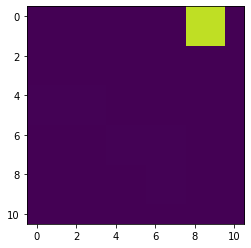

In [307]:
plt.imshow(xx_super[:, :, 0], vmax=1)

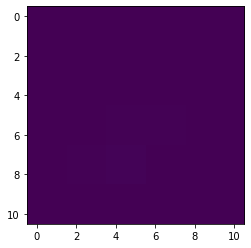

In [308]:
plt.imshow(xx_super[:, :, 1], vmax=1)

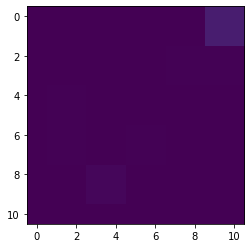

In [309]:
plt.imshow(xx_super[:, :, 2], vmax=1)

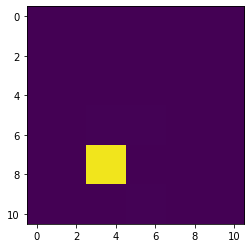

In [310]:
plt.imshow(xx_super[:, :, 3], vmax=1)

New estimate of number of objects in area

In [254]:
xx.sum()

tensor(2.1791, device='cuda:0')

Each individual estimate

In [255]:
reduce(log_probs_all.exp(), "nth ntw d -> d", "sum")

tensor([1.5529, 0.7751, 1.9657, 1.0799], device='cuda:0')

In [256]:
log_probs_all[:, :, 2].exp()

tensor([[1.0970e-04, 2.9603e-04, 2.4895e-04, 3.1255e-02, 8.3180e-01],
        [3.2226e-03, 1.2341e-03, 6.6641e-04, 4.7489e-03, 3.8752e-03],
        [3.9563e-03, 2.8148e-03, 3.0521e-03, 1.3038e-03, 8.4702e-04],
        [6.0909e-03, 1.5880e-01, 6.4805e-03, 1.7806e-03, 1.4328e-04],
        [1.4288e-03, 8.9808e-01, 4.4663e-04, 2.7102e-03, 3.3890e-04]],
       device='cuda:0')

The third set of disjoint tiles only happens to be close to the true because it under-estimates the object to the upper-right and over-estimates the object to the bottom-left.

In [257]:
log_probs_all.exp().sum() / 4

tensor(1.3434, device='cuda:0')

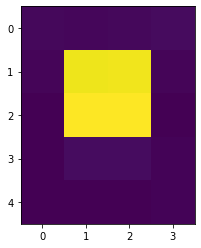

In [678]:
plt.imshow(xx_super[6:, 2:6])

In [679]:
xx_super[6:, 2:6].sum()

tensor(1.0467)

# Inference of non-overlapping subtiles

In [299]:
loc_means = torch.stack([t["loc_mean"][0, :, :, 0, :] for t in tile_maps], dim = -1)
loc_sds = torch.stack([t["loc_sd"][0, :, :, 0, :] for t in tile_maps], dim = -1)

In [263]:
loc_means.shape

torch.Size([5, 5, 2, 4])

In [262]:
loc_sds.shape

torch.Size([5, 5, 2, 4])

In [264]:
loc_means_h = loc_means[:, :, 0]
loc_means_w = loc_means[:, :, 1]
loc_sds_h = loc_sds[:, :, 0]
loc_sds_w = loc_sds[:, :, 1]
dist_h = torch.distributions.Normal(loc_means_h, loc_sds_h)
dist_w = torch.distributions.Normal(loc_means_w, loc_sds_w)

device = loc_means_h.device
start = torch.tensor(0.0, device = device)
mid = torch.tensor(0.5, device = device)
end = torch.tensor(1.0, device = device)

prob_h_top = (dist_h.cdf(mid) - dist_h.cdf(start)) / (dist_h.cdf(end) - dist_h.cdf(start))
prob_h_bot = 1 - prob_h_top
prob_h = torch.stack((prob_h_top, prob_h_bot), dim=-1)
prob_h = rearrange(prob_h, "nl nth ntw sh -> nl nth ntw sh 1", sh=2)

prob_w_left = (dist_w.cdf(mid) - dist_w.cdf(start)) / (dist_w.cdf(end) - dist_w.cdf(start)) 
prob_w_right = 1 - prob_w_left
prob_w = torch.stack((prob_w_left, prob_w_right), dim=-1)
prob_w = rearrange(prob_w, "nl nth ntw sw -> nl nth ntw 1 sw", sw=2)

probs_in_tile = prob_h * prob_w

In [265]:
probs_in_tile.shape

torch.Size([5, 5, 4, 2, 2])

In [ ]:
tile_samples

In [271]:
tiles_dbl = repeat(tile_samples, "ns h w d -> ns h w d h2 w2",h2=2, w2=2)

In [272]:
tiles_dbl.shape

torch.Size([10000, 5, 5, 4, 2, 2])

In [273]:
probs_in_subtiles = tiles_dbl * probs_in_tile.unsqueeze(0)

In [275]:
probs_in_subtiles.shape

torch.Size([10000, 5, 5, 4, 2, 2])

In [285]:
probs_subtiles = torch.zeros(xx_dbl.shape[0] + 1, xx_dbl.shape[1] + 1, device=probs_in_subtiles.device)

p2 = reduce(probs_in_subtiles, "ns nth ntw nl h2 w2 -> (nth h2) (ntw w2) nl", "mean")

probs_subtiles[:-1, :-1] += p2[:, :, 0]
probs_subtiles[1:, :-1] += p2[:, :, 1]
probs_subtiles[:-1, 1:] += p2[:, :, 2]
probs_subtiles[1:, 1:] += p2[:, :, 3]

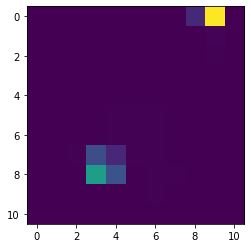

In [300]:
plt.imshow(probs_subtiles.cpu())

In [297]:
probs_subtiles[7:9, 3:5]

tensor([[0.2088, 0.0990],
        [0.4936, 0.2250]], device='cuda:0')

In [298]:
probs_subtiles[7:9, 3:5].sum()

tensor(1.0263, device='cuda:0')

In [302]:
probs_subtiles.sum()

tensor(2.1791, device='cuda:0')

In [301]:
9.7940e-01 * -1

-0.9794

In [320]:
probs_subtiles[:2, -3:]

tensor([[1.0055e-01, 8.8161e-01, 1.4148e-06],
        [1.7744e-03, 8.7538e-03, 1.8019e-04]], device='cuda:0')